NovaCred Data Quality Report: 

* I. Uniqueness: Identified 2 duplicate records (0.40%) based on the _id field and 3 based on the SSN field. Detected 2 cases of "Identity Conflict" where the same SSN is linked to different names, requiring high-priority governance flagging.
* II. Consistency: Mixed data types in annual_income (str,int,float) and inconsistent gender coding featuring six distinct variations (Male, M, F, Female, '', nan)
* III. Completeness: Missing values in ssn (1%), ip_address (1%), and annual_income (1%). Found that annual_income was missing in some records only because it was incorrectly labeled as annual_salary. Governance Gaps: Heavy missingness in processing_timestamp (87.6%) and loan_purpose (90.0%).
* IV. Validity: Negative values in credit_history_months, savings_balance, which is logically impossible. Ther is also one case of zero income. 
* V. Accuracy: Inconsistent date formats in date_of_birth mixing ISO standard (YYYY-MM-DD) with European formats (DD/MM/YYYY) preventing correct age calculation.

In [4]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib

# Load and flatten nested JSON
try:
    with open('../data/raw_credit_applications.json', 'r') as f:
        df = pd.json_normalize(json.load(f))
    print(f"[SYSTEM] Ingested {len(df)} records.")
except Exception as e:
    print(f"[ERROR] Ingestion failed: {e}")

[SYSTEM] Ingested 502 records.


## I. UNIQUENESS

In [6]:
print("I. UNIQUENESS\n")

# 1. Technical _id duplicates
id_counts = df['_id'].value_counts()
duplicate_ids = id_counts[id_counts > 1].index.tolist()
print(f"I.a Technical ID Duplicates: {len(duplicate_ids)}")
print(f"IDs with multiple entries: {duplicate_ids}")

# 2. Identity ssn duplicates
if 'applicant_info.ssn' in df.columns:
    # Total duplicates (includes NaNs)
    ssn_dupes_count = df.duplicated(subset=['applicant_info.ssn']).sum()
    
    # Non-N/A duplicates (actual identity repeats)
    ssn_clean_dupes = df.duplicated(subset=['applicant_info.ssn']).sum() - (df['applicant_info.ssn'].isna().sum() - 1)
    
    print(f"I.b Identity SSN Duplicates (Total): {ssn_dupes_count}")
    print(f"I.c Identity SSN Duplicates (Non-N/A): {ssn_clean_dupes}")

I. UNIQUENESS

I.a Technical ID Duplicates: 2
IDs with multiple entries: ['app_042', 'app_001']
I.b Identity SSN Duplicates (Total): 7
I.c Identity SSN Duplicates (Non-N/A): 3


In [7]:
# I.a DEEP DIVE: INVESTIGATING IDs app_042 & app_001
target_ids = ['app_042', 'app_001']

print("INVESTIGATING IDs app_042 & app_001")
for aid in target_ids:
    print(f"\nInspecting all instances for {aid}")
    # Displaying the full records to see the difference in populated fields
    display(df[df['_id'] == aid])

# Observation: 
# app_042 has identical data but index 354 includes a 'RESUBMISSION' note. 
# app_001 is a duplicaate entry error with lot of missing data in the second instance (index 455)

INVESTIGATING IDs app_042 & app_001

Inspecting all instances for app_042


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION



Inspecting all instances for app_001


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR


In [8]:
# I.b DEEP DIVE: IDENTITY INTEGRITY (SSN)
if 'applicant_info.ssn' in df.columns:
    # We drop NaNs first to find ACTUAL repeated SSNs
    clean_ssn_series = df['applicant_info.ssn'].dropna()
    ssn_counts = clean_ssn_series.value_counts()
    repeated_ssns = ssn_counts[ssn_counts > 1].index.tolist()
    
    print(f"INSPECTING ALL REPEATED SSNs (Excluding NaNs)")
    print(f"Number of unique SSNs repeated: {len(repeated_ssns)}")
    
    # Filtering for the records
    identity_audit = df[df['applicant_info.ssn'].isin(repeated_ssns)].sort_values(by='applicant_info.ssn')
    
    print(f"Total records involved in SSN duplicates: {len(identity_audit)}")
    display(identity_audit[['_id', 'applicant_info.ssn', 'applicant_info.full_name', 'applicant_info.date_of_birth']])

# Observation:
# The first SSN duplicate is the same duplicate as for app_042 we saw above.
# The two other SSN duplicates involve different names for the same SSN, which is a strong signal of identity integrity issues. This should be flagged.

INSPECTING ALL REPEATED SSNs (Excluding NaNs)
Number of unique SSNs repeated: 3
Total records involved in SSN duplicates: 6


,_id,applicant_info.ssn,applicant_info.full_name,applicant_info.date_of_birth
8,app_042,652-70-5530,Joseph Lopez,1990-05-04
354,app_042,652-70-5530,Joseph Lopez,1990-05-04
92,app_088,780-24-9300,Susan Martinez,1986-10-15
122,app_016,780-24-9300,Gary Wilson,1959-12-11
16,app_101,937-72-8731,Sandra Smith,1997-03-23
499,app_234,937-72-8731,Samuel Hill,1976/01/29


## II.  CONSISTENCY

In [9]:
print("II.  CONSISTENCY:\n")


# 1. Type Consistency (Annual Income)
print(f"II.a INCOME TYPES: {df['financials.annual_income'].apply(type).value_counts().to_dict()}")

# 2. Type Consistency (Gender)
if 'applicant_info.gender' in df.columns:
    print(f"II.b GENDER VARIATIONS: {df['applicant_info.gender'].unique().tolist()}")


II.  CONSISTENCY:

II.a INCOME TYPES: {<class 'int'>: 488, <class 'str'>: 8, <class 'float'>: 6}
II.b GENDER VARIATIONS: ['Male', 'M', 'F', 'Female', '', nan]


## III. COMPLETENESS

In [10]:
# Top Missing Fields by Percentage
print("III. COMPLETENESS:\n")

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
missing_report = pd.DataFrame({'counts': null_counts, 'pct': null_pct})
top_missing = missing_report[missing_report['counts'] > 0].sort_values(by='pct', ascending=False)
for field, row in top_missing.iterrows():
    print(f"{field:30} | {int(row['counts']):3} missing | {row['pct']:5.1f}%")

III. COMPLETENESS:

notes                          | 500 missing |  99.6%
financials.annual_salary       | 497 missing |  99.0%
loan_purpose                   | 452 missing |  90.0%
processing_timestamp           | 440 missing |  87.6%
decision.rejection_reason      | 292 missing |  58.2%
decision.interest_rate         | 210 missing |  41.8%
decision.approved_amount       | 210 missing |  41.8%
applicant_info.ssn             |   5 missing |   1.0%
applicant_info.ip_address      |   5 missing |   1.0%
financials.annual_income       |   5 missing |   1.0%
applicant_info.gender          |   1 missing |   0.2%
applicant_info.date_of_birth   |   1 missing |   0.2%
applicant_info.zip_code        |   1 missing |   0.2%


In [11]:
# III.a DEEP DIVE: FINANCIAL DATA INSPECTION (DISCOVERY)
print("INVESTIGATING MISSING INCOME DATA")

# Isolate records where annual_income is NaN
missing_income_df = df[df['financials.annual_income'].isna()]

print(f"Records missing 'annual_income': {len(missing_income_df)}")

if not missing_income_df.empty:
    print("\nDisplaying all financial columns for records with missing income to identify schema issues:")
    # We display the first 5 records but filter columns specifically related to financials
    # to find why the income data is 'missing'
    discovery_view = missing_income_df.head(5).filter(like='financials')
    display(discovery_view)

# Observation:
# The 'missing' income data is actually present but under a different field name 'annual_salary'. This indicates a schema inconsistency where some records use 'annual_income' and others use 'annual_salary' for the same data point. This should be standardized in the cleaning process.

INVESTIGATING MISSING INCOME DATA
Records missing 'annual_income': 5

Displaying all financial columns for records with missing income to identify schema issues:


,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,financials.annual_salary
76,NaN,35,0.13,10311,45000.0
94,NaN,44,0.06,5018,46000.0
99,NaN,56,0.11,15630,94000.0
141,NaN,50,0.29,66878,86000.0
149,NaN,86,0.07,27467,75000.0


## IV.   VALIDITY

In [12]:
print("IV.   VALIDITY\n")

# 1. Negative Values (History & Savings)
neg_history = (df['financials.credit_history_months'] < 0).sum()
neg_savings = (df['financials.savings_balance'] < 0).sum()
print(f"IV.a NEGATIVE VALUES: {neg_history} (History), {neg_savings} (Savings)")

# 2. Cross-Field Logic (Zero or Negative Income vs Active Records)
# Using <= 0 to capture anyone with no reported positive earnings
zero_or_neg_income = df[(df['financials.annual_income'] == 0)].shape[0]
print(f"IV.b LOGIC CHECK: Zero or Negative Income Applicants: {zero_or_neg_income}")

# 3. Outliers (Impossible History)
impossible_history = (df['financials.credit_history_months'] > 1200).sum()
print(f"IV.c RANGE VIOLATIONS (>100yrs): {impossible_history}")

IV.   VALIDITY

IV.a NEGATIVE VALUES: 2 (History), 1 (Savings)
IV.b LOGIC CHECK: Zero or Negative Income Applicants: 1
IV.c RANGE VIOLATIONS (>100yrs): 0


## V.  ACCURACY

In [13]:
print("V.  ACCURACY\n")
# Sample formats to detect mixed ISO vs European dates
if 'applicant_info.date_of_birth' in df.columns:
    print(f"V. DATE SAMPLES: {df['applicant_info.date_of_birth'].head(5).tolist()}")

V.  ACCURACY

V. DATE SAMPLES: ['2001-03-09', '1992-03-31', '1989-10-24', '1983-04-25', '1999-05-21']


## Visual 

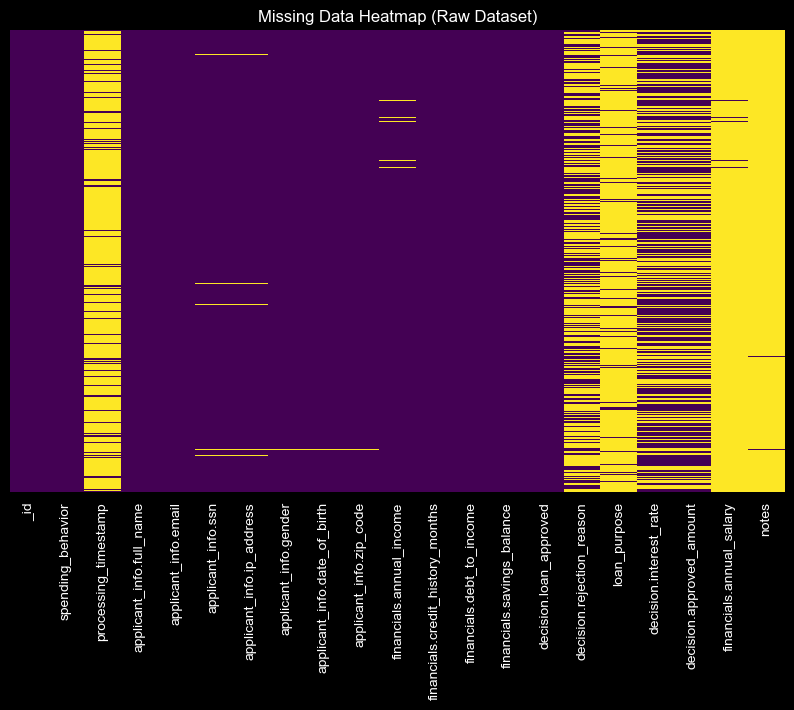

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# A quick heatmap to show missing data (yellow = missing)
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Raw Dataset)')
plt.show()

## Create clean copy

In [15]:
df_clean = df.copy()

# 1. FIX SCHEMA DRIFT (Income vs Salary)
# Before fixing types, fill the missing income with salary values found in discovery
if 'financials.annual_salary' in df_clean.columns:
    df_clean['financials.annual_income'] = df_clean['financials.annual_income'].fillna(df_clean['financials.annual_salary'])
    # Now we can drop the drift column as it's merged
    df_clean = df_clean.drop(columns=['financials.annual_salary'])

# 2. RESOLVE PARTIAL DUPLICATES (Keeping the 'Full' record)
# We count non-null values per row and sort so the most complete records are at the top
df_clean['completeness_score'] = df_clean.notnull().sum(axis=1)
df_clean = df_clean.sort_values(by=['_id', 'completeness_score'], ascending=[True, False])

# Drop duplicates but keep the first (which is now the most complete one)
df_clean = df_clean.drop_duplicates(subset=['_id'], keep='first')
df_clean = df_clean.drop(columns=['completeness_score'])

# 3. STANDARDIZE TYPES & FORMATS
df_clean['applicant_info.date_of_birth'] = pd.to_datetime(df_clean['applicant_info.date_of_birth'], dayfirst=True, errors='coerce')
df_clean['financials.annual_income'] = pd.to_numeric(df_clean['financials.annual_income'], errors='coerce')

# 4. STANDARDIZE CATEGORICAL & DOMAIN ERRORS
gender_map = {'Male': 'Male', 'M': 'Male', 'm': 'Male', 'Female': 'Female', 'F': 'Female', 'f': 'Female', '': np.nan}
df_clean['applicant_info.gender'] = df_clean['applicant_info.gender'].replace(gender_map)

# Set invalid negative values to NaN for validity
df_clean.loc[df_clean['financials.credit_history_months'] < 0, 'financials.credit_history_months'] = np.nan
df_clean.loc[df_clean['financials.savings_balance'] < 0, 'financials.savings_balance'] = np.nan

# 5. PRIVACY: PSEUDONYMIZATION (GDPR Compliance)
def hash_ssn(val):
    if pd.isna(val) or val == "": return val
    return hashlib.sha256(str(val).encode()).hexdigest()[:12]

df_clean['applicant_info.ssn'] = df_clean['applicant_info.ssn'].apply(hash_ssn)

print(f"Cleaning complete. Records remaining: {len(df_clean)}")

Cleaning complete. Records remaining: 500


/var/folders/7h/83z9_l6s1qq8srcz0xyd5_zr0000gn/T/ipykernel_3322/2893670246.py:20: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_clean['applicant_info.date_of_birth'] = pd.to_datetime(df_clean['applicant_info.date_of_birth'], dayfirst=True, errors='coerce')


In [16]:
# --- POST-REMEDIATION VERIFICATION REPORT ---

def generate_verification_report(df_new):
    print("\n" + "="*60)
    print(" NOVACRED DATA QUALITY VERIFICATION (POST-CLEANING)")
    print("="*60)
    
    # I. Duplicate Records
    dupes = df_new.duplicated(subset=['_id']).sum()
    status_i = "PASSED" if dupes == 0 else "FAILED"
    print(f"I.   UNIQUENESS: {dupes} duplicates remaining | STATUS: {status_i}")

    # II. Inconsistent Data Types
    print("\nII.  CONSISTENCY (DATA TYPES):")
    if 'financials.annual_income' in df_new.columns:
        types = df_new['financials.annual_income'].apply(type).value_counts()
        is_float_only = all(t == type(0.0) for t in types.index)
        status_ii = "PASSED" if is_float_only else "FAILED"
        for dtype, count in types.items():
            print(f"     - financials.annual_income | {dtype}: {count}")
        print(f"     STATUS: {status_ii}")

    # III. Missing or Incomplete Records
    print("\nIII. COMPLETENESS (REMAINING NULLS):")
    null_total = df_new.isnull().sum().sum()
    # Note: Some nulls are expected (e.g., rejection_reason for approved loans)
    print(f"     - Total null values across dataset: {null_total}")
    print(f"     - Record count: {len(df_new)}")

    # IV. Inconsistent Coding/Formatting (Categorical)
    print("\nIV.  CONSISTENCY (CATEGORICAL CODING):")
    if 'applicant_info.gender' in df_new.columns:
        unique_vals = df_new['applicant_info.gender'].unique().tolist()
        # Logic check: Should only contain ['Male', 'Female', nan]
        expected = {'Male', 'Female', np.nan}
        is_standardized = set(unique_vals).issubset(expected)
        status_iv = "PASSED" if is_standardized else "FAILED"
        print(f"     - applicant_info.gender | Observed: {unique_vals}")
        print(f"     STATUS: {status_iv}")

    # V. Invalid or Impossible Values
    print("\nV.   VALIDITY (DOMAIN CONSTRAINTS):")
    if 'financials.credit_history_months' in df_new.columns:
        invalid = (df_new['financials.credit_history_months'] < 0).sum()
        status_v = "PASSED" if invalid == 0 else "FAILED"
        print(f"     - financials.credit_history_months | Negatives: {invalid}")
        print(f"     STATUS: {status_v}")

    # VI. Inconsistent Date Formats
    print("\nVI.  ACCURACY (TEMPORAL FORMATS):")
    is_dt = pd.api.types.is_datetime64_any_dtype(df_new['applicant_info.date_of_birth'])
    status_vi = "PASSED" if is_dt else "FAILED"
    print(f"     - applicant_info.date_of_birth | Datetime Object: {is_dt}")
    print(f"     STATUS: {status_vi}")
    
    print("="*60)

# Run the verification on your cleaned dataframe
generate_verification_report(df_clean)


 NOVACRED DATA QUALITY VERIFICATION (POST-CLEANING)
I.   UNIQUENESS: 0 duplicates remaining | STATUS: PASSED

II.  CONSISTENCY (DATA TYPES):
     - financials.annual_income | <class 'float'>: 500
     STATUS: PASSED

III. COMPLETENESS (REMAINING NULLS):
     - Total null values across dataset: 2269
     - Record count: 500

IV.  CONSISTENCY (CATEGORICAL CODING):
     - applicant_info.gender | Observed: ['Female', 'Male', nan]
     STATUS: PASSED

V.   VALIDITY (DOMAIN CONSTRAINTS):
     - financials.credit_history_months | Negatives: 0
     STATUS: PASSED

VI.  ACCURACY (TEMPORAL FORMATS):
     - applicant_info.date_of_birth | Datetime Object: True
     STATUS: PASSED


In [20]:
# Save the cleaned and protected data to the project's data directory
df_clean.to_csv('../data/cleaned_credit_datav2.csv', index=False)
print("File saved locally to the /data folder.")

File saved locally to the /data folder.
